[Reference](https://medium.com/mlworks/top-5-dimensionality-reduction-techniques-039ac4ac08c7)

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

## Loading and Scaling the Dataset

In [2]:
# Load dataset (Iris)
iris = datasets.load_iris()
X = iris.data # 150 records, with 4 features.
y = iris.target
target_names = iris.target_names # 3 classes

# Standardize features
X_scaled = StandardScaler().fit_transform(X)

## Loading and Scaling the Dataset

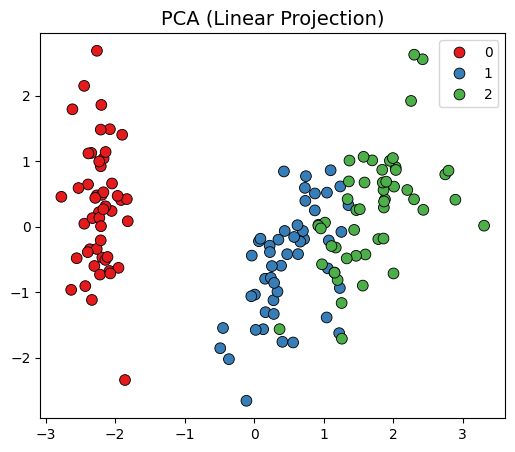

In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y,
                palette="Set1", s=60, edgecolor='k')
plt.title("PCA (Linear Projection)", fontsize=14)
plt.show()

## t-SNE

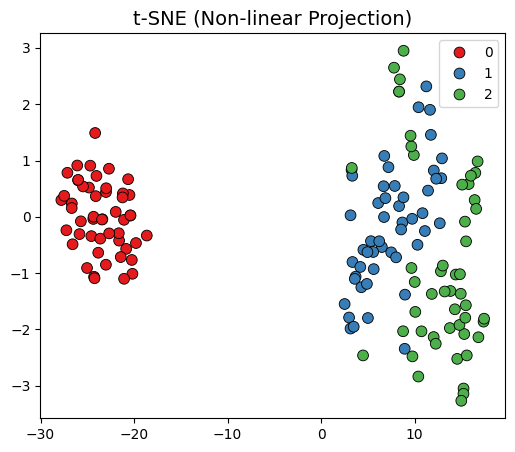

In [4]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y,
                palette="Set1", s=60, edgecolor='k')
plt.title("t-SNE (Non-linear Projection)", fontsize=14)
plt.show()

## UMAP

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


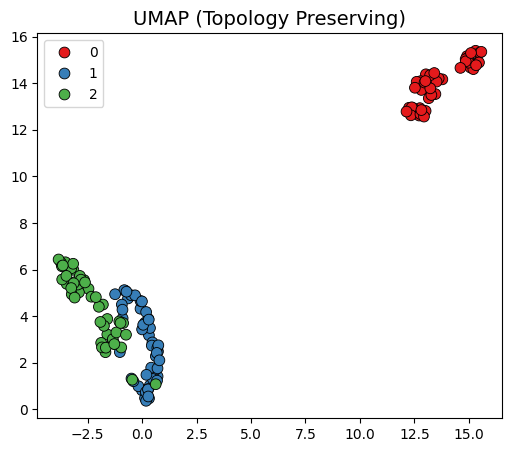

In [5]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=y,
                palette="Set1", s=60, edgecolor='k')
plt.title("UMAP (Topology Preserving)", fontsize=14)
plt.show()

## LDA

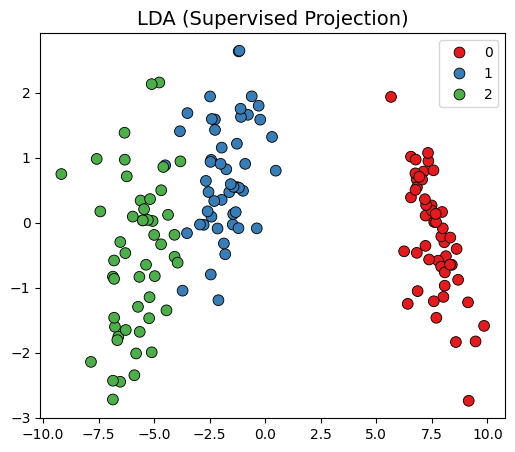

In [6]:
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_lda[:,0], y=X_lda[:,1], hue=y,
                palette="Set1", s=60, edgecolor='k')
plt.title("LDA (Supervised Projection)", fontsize=14)
plt.show()

## Autoencoder

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


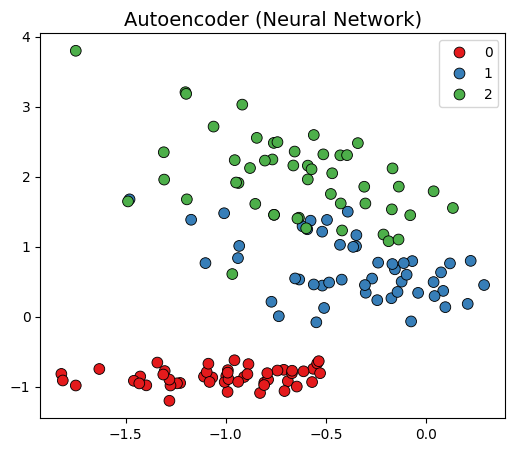

In [7]:
input_dim = X_scaled.shape[1]
encoding_dim = 2

# Define encoder
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(8, activation='relu')(input_layer)
bottleneck = layers.Dense(encoding_dim, activation=None)(encoded)

# Decoder
decoded = layers.Dense(8, activation='relu')(bottleneck)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# Autoencoder model
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Train
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=16, verbose=0)

# Extract encoder model
encoder = models.Model(inputs=input_layer, outputs=bottleneck)
X_ae = encoder.predict(X_scaled)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_ae[:,0], y=X_ae[:,1], hue=y,
                palette="Set1", s=60, edgecolor='k')
plt.title("Autoencoder (Neural Network)", fontsize=14)
plt.show()

In [8]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

## Combining the five results

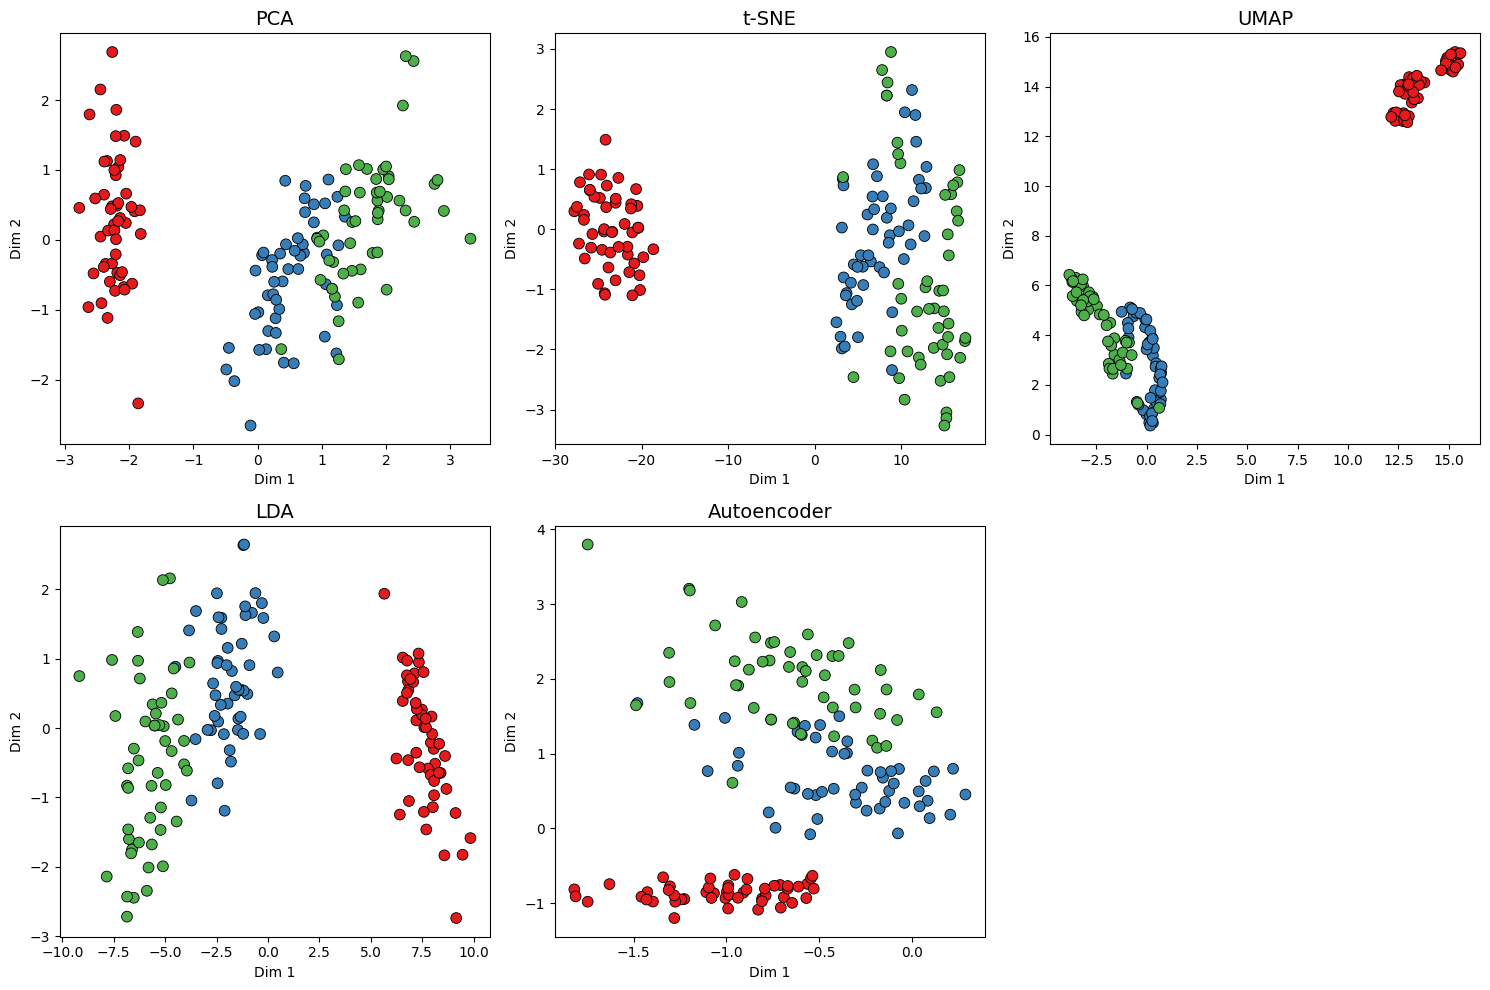

In [9]:
methods = {
    "PCA": X_pca,
    "t-SNE": X_tsne,
    "UMAP": X_umap,
    "LDA": X_lda,
    "Autoencoder": X_ae
}

plt.figure(figsize=(15, 10))

for i, (name, X_embedded) in enumerate(methods.items(), 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y,
                    palette="Set1", s=60, edgecolor='k')
    plt.title(name, fontsize=14)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.legend([],[], frameon=False)  # hide legend for cleaner view

plt.tight_layout()
plt.show()